In [20]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [21]:
# Load data
train = pd.read_csv("/content/train_KNN (3).csv")
test = pd.read_csv("/content/test_KNN (3).csv")

In [22]:
# Preprocessing
def preprocess(df):
    df = df.copy()

    # Drop useless columns
    df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True, errors='ignore')

    # Handle missing values
    df["Age"] = df["Age"].fillna(df["Age"].median())
    if "Fare" in df.columns:
        df["Fare"] = df["Fare"].fillna(df["Fare"].median())

    # Drop rows where Embarked is missing (like your class code)
    df = df.dropna(subset=["Embarked"])

    # Convert categorical to dummies
    df = pd.get_dummies(df, drop_first=True)

    return df


train = preprocess(train)
test = preprocess(test)
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [23]:
# Split features and target
X_train = train.drop("Survived", axis=1)
y_train = train["Survived"]

X_test = test.drop("Survived", axis=1)
y_test = test["Survived"]

In [24]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)

In [26]:
# Logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)

In [27]:
# Decision tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)


=== MODEL PERFORMANCE ===
                 Model  Accuracy
0                  KNN  0.813397
1  Logistic Regression  0.942584
2        Decision Tree  0.954545


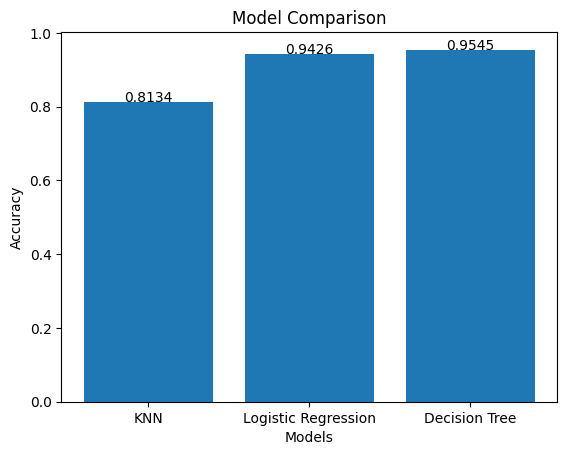

In [28]:
# Comparing the models
results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [knn_acc, lr_acc, dt_acc]
})

print("\n=== MODEL PERFORMANCE ===")
print(results)

models = ["KNN", "Logistic Regression", "Decision Tree"]
accuracies = [
    accuracy_score(y_test, y_pred_knn),   # KNN
    lr_acc,                          # Logistic Regression
    dt_acc                           # Decision Tree
]

# Plot
plt.figure()
plt.bar(models, accuracies)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, str(round(v, 4)), ha='center')

plt.show()

In [29]:
# Classification reports for each model
print("\n--- KNN Report ---")
print(classification_report(y_test, y_pred_knn))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, y_pred_dt))


--- KNN Report ---
              precision    recall  f1-score   support

           0       0.89      0.80      0.85       266
           1       0.71      0.84      0.77       152

    accuracy                           0.81       418
   macro avg       0.80      0.82      0.81       418
weighted avg       0.83      0.81      0.82       418


--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       266
           1       0.91      0.94      0.92       152

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.94      0.94      0.94       418


--- Decision Tree Report ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       266
           1       0.95      0.93      0.94       152

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.9

Findings

KNN Accuracy: 0.8134

Performs well after scaling

Sensitive to value of k

Logistic Regression Accuracy: 0.9426

Stable and consistent performance

Works well for linear relationships

Decision Tree Accuracy: 0.9545

Captures non-linear patterns

Risk of overfitting (controlled using depth)

Comparison

Highest Accuracy: Decision Tree Classifier

Most Stable Model: Logistic Regression

Most Interpretable Model: Decision Tree

Logistic Regression gives balanced performance

Decision Tree is useful for understanding patterns

KNN is sensitive but effective with tuning